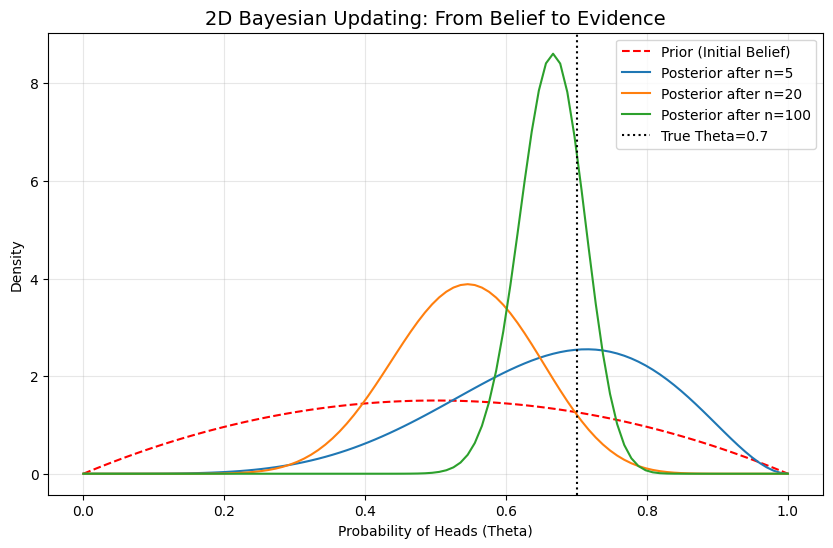

✅ 3D Asset saved: ../../../assets\59_bayesian_3d.png


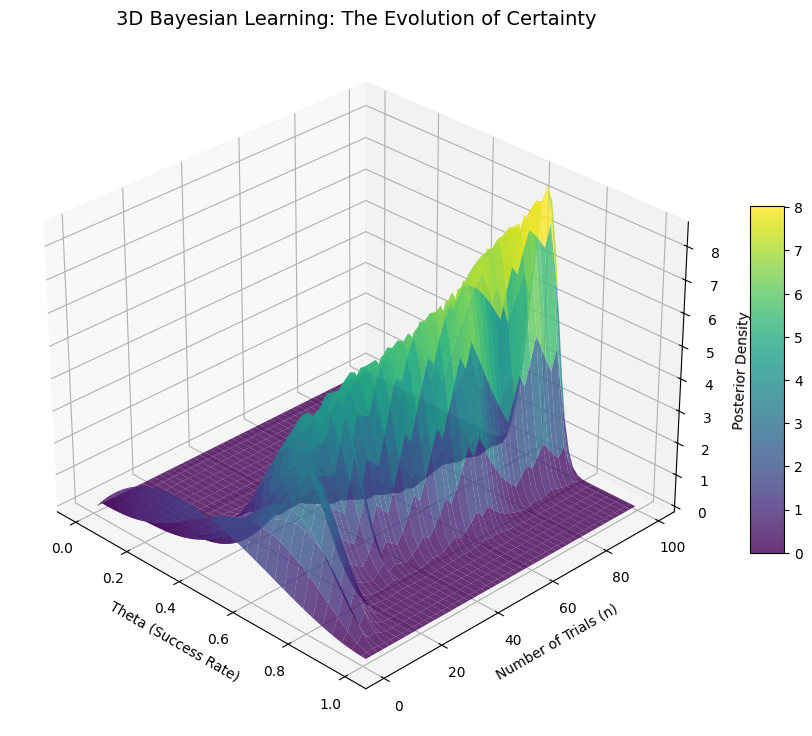

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import os

def run_bayesian_master():
    # --- PROFESSIONAL PATH SETUP (Relative Path) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Simulation: Estimating the "Fairness" of a Coin (Theta)
    # True Theta = 0.7 (It's a biased coin)
    true_theta = 0.7
    n_trials = 100
    data = np.random.binomial(1, true_theta, n_trials)
    
    # 2. Sequential Updating (Using Beta-Binomial Conjugate)
    # Prior: Alpha=2, Beta=2 (A weak belief that it might be fair)
    alpha_prior, beta_prior = 2, 2
    
    # --- 📸 ASSET 1: POSTERIOR UPDATING STEPS (59_bayesian_2d.png) ---
    plt.figure(figsize=(10, 6))
    x = np.linspace(0, 1, 100)
    
    # Plot Prior
    plt.plot(x, beta.pdf(x, alpha_prior, beta_prior), 'r--', label='Prior (Initial Belief)')
    
    # Update with different amounts of data
    for n in [5, 20, 100]:
        heads = np.sum(data[:n])
        tails = n - heads
        a_post = alpha_prior + heads
        b_post = beta_prior + tails
        plt.plot(x, beta.pdf(x, a_post, b_post), label=f'Posterior after n={n}')

    plt.axvline(true_theta, color='black', linestyle=':', label=f'True Theta={true_theta}')
    plt.title("2D Bayesian Updating: From Belief to Evidence", fontsize=14)
    plt.xlabel("Probability of Heads (Theta)"); plt.ylabel("Density")
    plt.legend(); plt.grid(alpha=0.3)
    
    save_path_2d = os.path.join(asset_path, '59_bayesian_2d.png')
    plt.savefig(save_path_2d, dpi=300)
    plt.show()

    # --- 📸 ASSET 2: 3D LEARNING LANDSCAPE (59_bayesian_3d.png) ---
    fig = plt.figure(figsize=(12, 9))
    ax3d = fig.add_subplot(111, projection='3d')
    
    N_steps = np.arange(1, n_trials + 1, 2)
    X_val = np.linspace(0, 1, 60)
    X_grid, N_grid = np.meshgrid(X_val, N_steps)
    Z_density = np.zeros_like(X_grid)

    for i, n in enumerate(N_steps):
        heads = np.sum(data[:n])
        tails = n - heads
        Z_density[i, :] = beta.pdf(X_val, alpha_prior + heads, beta_prior + tails)

    surf = ax3d.plot_surface(X_grid, N_grid, Z_density, cmap='viridis', alpha=0.8, edgecolor='none')
    
    ax3d.set_title("3D Bayesian Learning: The Evolution of Certainty", fontsize=14)
    ax3d.set_xlabel("Theta (Success Rate)"); ax3d.set_ylabel("Number of Trials (n)"); ax3d.set_zlabel("Posterior Density")
    fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10)
    
    ax3d.view_init(elev=30, azim=-45)

    save_path_3d = os.path.join(asset_path, '59_bayesian_3d.png')
    plt.savefig(save_path_3d, dpi=300)
    print(f"✅ 3D Asset saved: {save_path_3d}")
    plt.show()

if __name__ == "__main__":
    run_bayesian_master()